In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Polars:", pl.__version__)
print("NumPy:", np.__version__)

Polars: 1.44.2
NumPy: 2.5.3


# Carga de los Datos Crudos

In [2]:
from pathlib import Path
import sys

RUTA_PROYECTO = Path.cwd().parent
sys.path.append(str(RUTA_PROYECTO))

In [3]:
from config.rutas import (
    RUTA_PROYECTO,
    RUTA_DATA_RAW,
    RUTA_DATA_PROCESSED,
    RUTA_ENDIREH_CSV,
)

df_crudo = pl.read_csv(RUTA_ENDIREH_CSV)


# Exploracion inicial

Antes de realizar el análisis exploratorio y calcular las medidas descriptivas, se realiza una revisión de la calidad de los datos.

El preprocesamiento contempla:

- revisión de la estructura del dataset;
- identificación de valores faltantes;
- revisión de los tipos de datos;
- identificación de posibles códigos especiales;

In [4]:
print(f"Número de filas: {df_crudo.height}")
print(f"Número de columnas: {df_crudo.width}")

Número de filas: 110127
Número de columnas: 24


In [5]:
#Revisamos los nombres  y tipos de datos de las columnas
df_crudo.schema

Schema([('cve_entidad', Int64),
        ('nom_entidad', String),
        ('cve_municipio', Int64),
        ('nom_municipio', String),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad', String),
        ('estado_civil_id', Int64),
        ('estado_civil_desc', String),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Int64),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Int64),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Int64),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Int64),
        ('tiene_ahorros_desc', String),
        ('propietaria_vivienda_id', Int64),
        ('propietaria_vivienda_desc', String),
        ('sufrio_violencia_pareja', Int64),
        ('factor_expansion', Int64),
        ('anio_encuesta', Int64)])

In [6]:
# Detectamos valores nulos
resumen_nulos = pl.DataFrame({
    "variable": df_crudo.columns,
    "nulos": [
        df_crudo[columna].null_count()
        for columna in df_crudo.columns
    ]
})


resumen_nulos.filter(
    pl.col("nulos") > 0
).sort(
    "nulos",
    descending=True
)

variable,nulos
str,i64
"""edad_primer_union""",85567
"""ingreso_pareja""",61147
"""num_hijos""",19436


In [7]:
# Detectamos filas completamente idénticas
duplicados_exactos = df_crudo.is_duplicated().sum()

print(
    f"Filas completamente idénticas detectadas: "
    f"{duplicados_exactos}"
)


Filas completamente idénticas detectadas: 7882


In [8]:
# Revisamos valores únicos de variables importantes
# Revisamos cuantas mujeres han sufrido violencia por parte de su pareja
df_crudo.group_by(
    "sufrio_violencia_pareja"
).len().sort(
    "sufrio_violencia_pareja"
)


sufrio_violencia_pareja,len
i64,u32
0,90821
1,19306


In [9]:
# Revisamos el nivel de escolaridad de las mujeres encuestadas
df_crudo.group_by(
    "nivel_escolaridad"
).len().sort(
    "len",
    descending=True
)

nivel_escolaridad,len
str,u32
"""A1""",66131
"""C1""",14587
"""B1""",12598
"""B2""",9553
"""C2""",4849
"""A2""",2409


In [10]:
# Revisamos el estado civil de las mujeres encuestadas
df_crudo.group_by(
    "estado_civil_desc"
).len().sort(
    "len",
    descending=True
)

estado_civil_desc,len
str,u32
"""Casada""",44977
"""Unión libre""",23597
"""Soltera""",20002
"""Viuda""",9750
"""Separada""",8628
"""Divorciada""",3173


In [11]:
# Revisamos la edad de primer unión de las mujeres encuestadas
df_crudo.group_by(
    "edad_primer_union"
).len().sort(
    "edad_primer_union"
)

edad_primer_union,len
f64,u32
null,85567
0.0,3478
1.0,2015
2.0,1740
3.0,1487
…,…
72.0,1
74.0,1
76.0,1


In [12]:
# Revisamos el número de hijos de las mujeres encuestadas
df_crudo.group_by(
    "num_hijos"
).len().sort(
    "num_hijos"
)

num_hijos,len
f64,u32
null,19436
1.0,31398
2.0,2115
3.0,36019
4.0,21159


In [13]:
# Revisamos el ingreso de la pareja de las mujeres encuestadas
df_crudo.select(
    "ingreso_pareja"
).drop_nulls().sort(
    "ingreso_pareja",
    descending=True
).head(20)

ingreso_pareja
f64
9.99999e5
9.99999e5
9.99999e5
9.99999e5
9.99999e5
…
9.99999e5
9.99999e5
9.99999e5


In [14]:
df_crudo.filter(
    pl.col("edad_primer_union").is_in([0, 1, 2, 3, 98, 99])
).group_by(
    "edad_primer_union"
).len()

edad_primer_union,len
f64,u32
3.0,1487
98.0,656
0.0,3478
99.0,227
2.0,1740
1.0,2015


# Preprocesamiento de los datos
A partir de la exploración inicial se identificaron valores faltante y variables cuyo tipo de dato debe revisarse.

In [15]:
df = df_crudo.clone()

In [16]:
# Normalizamos variables de texto
columnas_texto = [
    columna
    for columna, tipo in df.schema.items()
    if tipo == pl.String
]

# Quitamos espacios en blanco al inicio y final de las cadenas de texto
df = df.with_columns([
    pl.col(columna)
    .str.strip_chars()
    .alias(columna)

    for columna in columnas_texto
])

# Reemplazamos cadenas vacías por valores nulos
df = df.with_columns([
    pl.when(
        pl.col(columna) == ""
    )
    .then(None)
    .otherwise(
        pl.col(columna)
    )
    .alias(columna)

    for columna in columnas_texto
])

In [17]:
#Corregimos tipos de datos
df = df.with_columns([
    pl.col("edad_primer_union")
    .cast(pl.Int64, strict=False),

    pl.col("num_hijos")
    .cast(pl.Int64, strict=False),

    pl.col("sufrio_violencia_pareja")
    .cast(pl.Int8),

    pl.col("anio_encuesta")
    .cast(pl.Int16)
])



In [18]:
# Las edades de primer unión válidas son entre 10 y 97 años, por lo que reemplazamos los valores fuera de este rango por nulos
df = df.with_columns(
    pl.when(
        pl.col("edad_primer_union").is_between(10, 97)
    )
    .then(
        pl.col("edad_primer_union")
    )
    .otherwise(None)
    .alias("edad_primer_union")
)

In [19]:
# Guardamos el DataFrame limpio en un archivo CSV
RUTA_SALIDA = RUTA_DATA_PROCESSED / "endireh_2021_limpio.csv"

df.write_csv(RUTA_SALIDA)

print(f"Archivo guardado en: {RUTA_SALIDA}")

Archivo guardado en: /Users/eidr1an/Documents/Almacenes/proyecto-endireh-violencia/data/data-processed/endireh_2021_limpio.csv


# Análisis Exploratorio de Datos

## Distribución de violencia de pareja


In [20]:
# Distribución de violencia de pareja
violencia = (
    df.group_by("sufrio_violencia_pareja")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("sufrio_violencia_pareja")
)

violencia

sufrio_violencia_pareja,len,porcentaje
i8,u32,f64
0,90821,82.47
1,19306,17.53


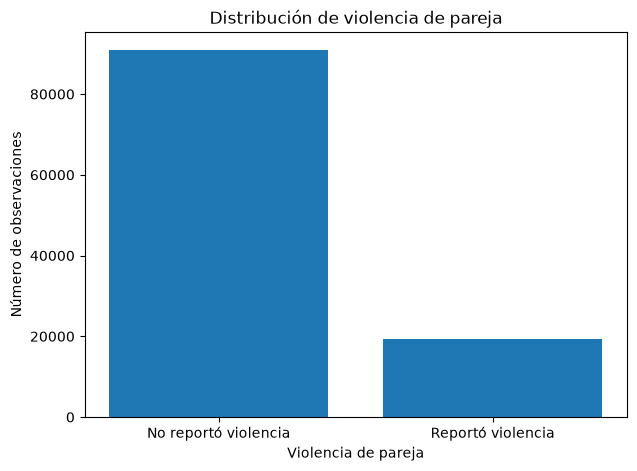

In [21]:
violencia_plot = violencia.sort("sufrio_violencia_pareja")

categorias = [
    "No reportó violencia",
    "Reportó violencia"
]

frecuencias = violencia_plot["len"].to_list()

plt.figure(figsize=(7, 5))
plt.bar(categorias, frecuencias)

plt.title("Distribución de violencia de pareja")
plt.ylabel("Número de observaciones")
plt.xlabel("Violencia de pareja")

plt.show()

## Nivel de escolaridad

In [22]:
escolaridad = (
    df.group_by("nivel_escolaridad")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("len", descending=True)
)

escolaridad

nivel_escolaridad,len,porcentaje
str,u32,f64
"""A1""",66131,60.05
"""C1""",14587,13.25
"""B1""",12598,11.44
"""B2""",9553,8.67
"""C2""",4849,4.4
"""A2""",2409,2.19


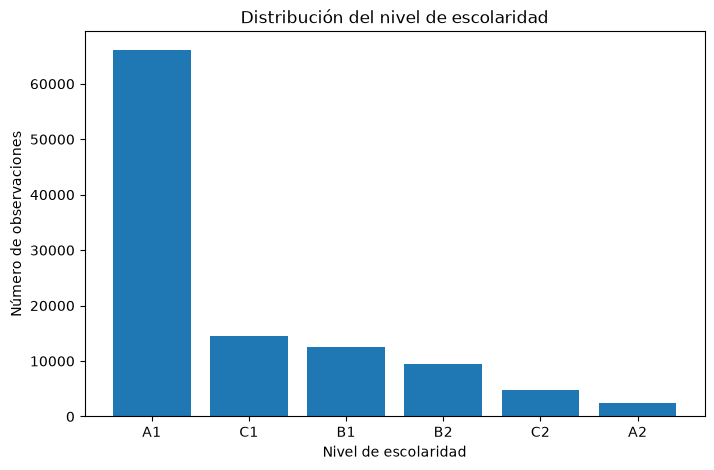

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    escolaridad["nivel_escolaridad"].to_list(),
    escolaridad["len"].to_list()
)

plt.title("Distribución del nivel de escolaridad")
plt.xlabel("Nivel de escolaridad")
plt.ylabel("Número de observaciones")

plt.show()

## Estado civil

In [24]:
estado_civil = (
    df.group_by("estado_civil_desc")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("len", descending=True)
)

estado_civil

estado_civil_desc,len,porcentaje
str,u32,f64
"""Casada""",44977,40.84
"""Unión libre""",23597,21.43
"""Soltera""",20002,18.16
"""Viuda""",9750,8.85
"""Separada""",8628,7.83
"""Divorciada""",3173,2.88


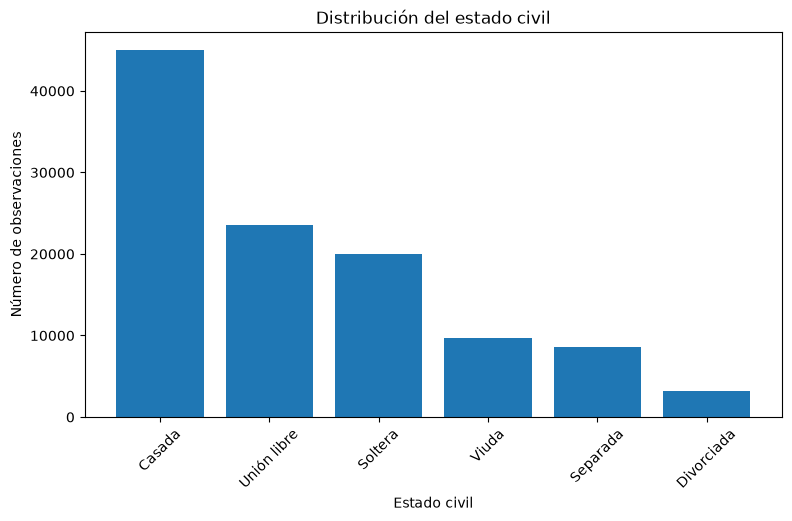

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    estado_civil["estado_civil_desc"].to_list(),
    estado_civil["len"].to_list()
)

plt.title("Distribución del estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Número de observaciones")

plt.xticks(rotation=45)

plt.show()

## Distribución de edad_primer_union

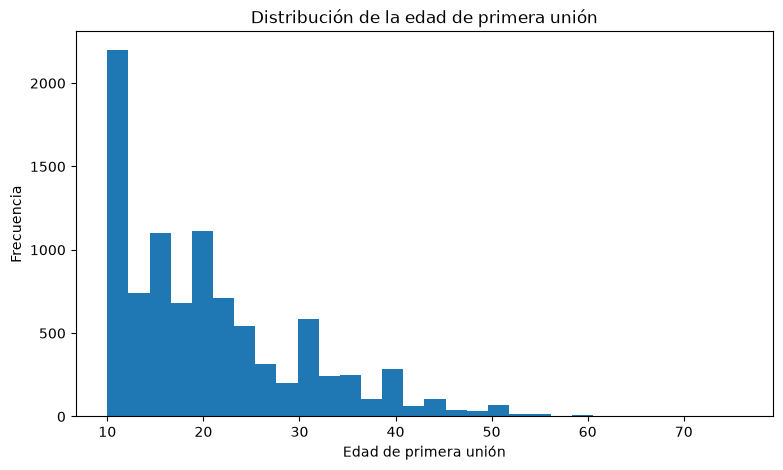

In [26]:
edades = (
    df.select("edad_primer_union")
    .drop_nulls()
    ["edad_primer_union"]
    .to_numpy()
)

plt.figure(figsize=(9, 5))

plt.hist(
    edades,
    bins=30
)

plt.title("Distribución de la edad de primera unión")
plt.xlabel("Edad de primera unión")
plt.ylabel("Frecuencia")

plt.show()

# Medidas de localización

In [27]:
resumen_localizacion = df.select([
    pl.col("edad_primer_union").mean().alias("media_edad"),
    pl.col("edad_primer_union").median().alias("mediana_edad"),
    pl.col("edad_primer_union").quantile(0.10).alias("P10_edad"),
    pl.col("edad_primer_union").quantile(0.25).alias("Q1_edad"),
    pl.col("edad_primer_union").quantile(0.50).alias("Q2_edad"),
    pl.col("edad_primer_union").quantile(0.75).alias("Q3_edad"),
    pl.col("edad_primer_union").quantile(0.90).alias("P90_edad"),
    pl.col("nivel_escolaridad").mode().first().alias("moda_escolaridad"),
])
print(resumen_localizacion)

shape: (1, 8)
┌────────────┬──────────────┬──────────┬─────────┬─────────┬─────────┬──────────┬──────────────────┐
│ media_edad ┆ mediana_edad ┆ P10_edad ┆ Q1_edad ┆ Q2_edad ┆ Q3_edad ┆ P90_edad ┆ moda_escolaridad │
│ ---        ┆ ---          ┆ ---      ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---              │
│ f64        ┆ f64          ┆ f64      ┆ f64     ┆ f64     ┆ f64     ┆ f64      ┆ str              │
╞════════════╪══════════════╪══════════╪═════════╪═════════╪═════════╪══════════╪══════════════════╡
│ 20.58122   ┆ 18.0         ┆ 10.0     ┆ 13.0    ┆ 18.0    ┆ 25.0    ┆ 35.0     ┆ A1               │
└────────────┴──────────────┴──────────┴─────────┴─────────┴─────────┴──────────┴──────────────────┘


In [28]:
df_edad = df.drop_nulls(
    subset=["edad_primer_union", "factor_expansion"]
)
edad = df_edad["edad_primer_union"].to_numpy()
pesos = df_edad["factor_expansion"].to_numpy()
media_simple = df_edad["edad_primer_union"].mean()
media_ponderada = np.average(edad, weights=pesos)
print(f"Media simple: {media_simple:.2f}")
print(f"Media ponderada: {media_ponderada:.2f}")

Media simple: 20.58
Media ponderada: 20.34


In [29]:
resumen_hijos = df.select([
    pl.col("num_hijos").mode().first().alias("moda_num_hijos"),
    pl.col("num_hijos").median().alias("mediana_num_hijos")
])
print(resumen_hijos)

shape: (1, 2)
┌────────────────┬───────────────────┐
│ moda_num_hijos ┆ mediana_num_hijos │
│ ---            ┆ ---               │
│ i64            ┆ f64               │
╞════════════════╪═══════════════════╡
│ 3              ┆ 3.0               │
└────────────────┴───────────────────┘


# Medidas de variabilidad

In [30]:
def medidas_variabilidad(df_grupo):
    datos = df_grupo.drop_nulls(
        subset=["edad_primer_union"]
    )

    q1 = datos["edad_primer_union"].quantile(0.25)
    q3 = datos["edad_primer_union"].quantile(0.75)

    media = datos["edad_primer_union"].mean()
    desviacion = datos["edad_primer_union"].std()

    rango = (
        datos["edad_primer_union"].max()
        - datos["edad_primer_union"].min()
    )

    varianza = datos["edad_primer_union"].var()
    cv = (desviacion / media) * 100
    iqr = q3 - q1

    return {
        "Rango": rango,
        "Varianza": varianza,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": f"% {cv:.2f}",
        "IQR": iqr
    }


sin_violencia = df.filter(
    pl.col("sufrio_violencia_pareja") == 0
)

con_violencia = df.filter(
    pl.col("sufrio_violencia_pareja") == 1
)

medidas_sin = medidas_variabilidad(sin_violencia)
medidas_con = medidas_variabilidad(con_violencia)


tabla_variabilidad = pl.DataFrame(
    {
    "Dato": list(medidas_sin.keys()),
    "Sin violencia de pareja": list(medidas_sin.values()),
    "Con violencia de pareja": list(medidas_con.values())
    },
    strict=False 
)

pl.Config.set_tbl_hide_column_data_types(True)

tabla_variabilidad

Dato,Sin violencia de pareja,Con violencia de pareja
"""Rango""","""66""","""62"""
"""Varianza""","""94.829436038136""","""87.36422291841221"""
"""Desviación estándar""","""9.738040667307567""","""9.346883058988821"""
"""Coeficiente de variación""","""% 46.99""","""% 45.98"""
"""IQR""","""13.0""","""12.0"""
